In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
from scipy.special import jn
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter

#import jcamp as jc

In [14]:


# Load the file. We use allow_pickle=True because it contains a Python dictionary.
# The .item() extracts the dictionary from the 0-D numpy array it gets wrapped in.
data = np.load('processed_data/urban/urban_processed_data.npy', allow_pickle=True).item()

# 1. See what keys are inside
print("Keys in the dataset:", data.keys())

# 1. Let's check X just to be sure it IS an array
print("Type of X:", type(data['X']))
if hasattr(data['X'], 'shape'):
    print("Shape of X:", data['X'].shape)

# 2. Let's peek inside the dictionary 'A'
print("\nType of A:", type(data['A']))
if isinstance(data['A'], dict):
    print("Keys inside A:", data['A'].keys())

# 3. Let's peek inside the dictionary 'S'
print("\nType of S:", type(data['S']))
if isinstance(data['S'], dict):
    print("Keys inside S:", data['S'].keys())

# 3. (Optional) Look at a small slice of the actual numbers
#print("\nFirst pixel's spectra in X:\n", data['X'][0, 0, :])

FileNotFoundError: [Errno 2] No such file or directory: 'processed_data/urban/urban_processed_data.npy'

In [ ]:
A_list= data['A']
S_list = data['S']


X = data['X']

S_gt = S_list['S_ref']
A_gt = A_list['A_ref']
# k = 4 for this dataset


print(S_gt.shape)
print(A_gt.shape)

NameError: name 'data' is not defined

In [ ]:
# Load the file. We use allow_pickle=True because it contains a Python dictionary.
# The .item() extracts the dictionary from the 0-D numpy array it gets wrapped in.
data = np.load('processed_data\jasper\data.npy', allow_pickle=True).item()

# 1. See what keys are inside
print("Keys in the dataset:", data.keys())

# 2. Inspect the exact shapes of the arrays
print("Shape of X (HSI Image):", data['X'].shape)
print("Shape of A_gt (Abundance Map):", data['A_gt'].shape)
print("Shape of S_gt (Endmember Spectra):", data['S_gt'].shape)

# 3. (Optional) Look at a small slice of the actual numbers
#print("\nFirst pixel's spectra in X:\n", data['X'][0, 0, :])

Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (HSI Image): (100, 100, 198)
Shape of A_gt (Abundance Map): (4, 10000)
Shape of S_gt (Endmember Spectra): (198, 4)


(10, 250, 30)
(30, 2)
(2, 2500)
[[0.37568365 0.94831811 0.73094146 ... 0.86370399 0.97815869 0.40852473]
 [0.62431635 0.05168189 0.26905854 ... 0.13629601 0.02184131 0.59147527]]


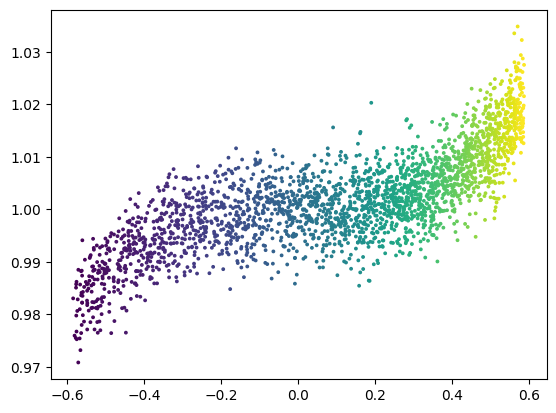

In [15]:
# Generate nonlinear synthetic data
num_points = 2500 # Reduced from 10000
h=10
error_std = 0.005
power = 3
start_end = 1.7
fl = 10
dims = 30

np.random.seed(42) # Set the seed
labels =  np.random.uniform(low=1/np.exp(1/start_end), high=np.exp(1/start_end), size=num_points)
s_l = 1/np.exp(1/start_end)
e_l = np.exp(1/start_end)
true = [s_l,e_l]

colors =( labels - np.min(labels))/(np.max(labels) - np.min(labels)+0.01)+0.005

noise = np.random.normal(loc=0.0, scale=error_std, size=labels.shape)
X_data = np.log(labels) 
x_true = np.log(true)
Y_data_pure = 1/fl*np.power(X_data,power)+1
y_true = 1/fl*np.power(x_true,power)+1
Y_data = Y_data_pure + noise
plt.scatter(X_data, Y_data, s= 3, c = colors)

embedding_mat = np.abs(np.random.normal(loc = 12, scale = 0.5, size =(dims,2) ))+0.00001

raw_data = embedding_mat @ [X_data, Y_data]



end_members = embedding_mat@[x_true,y_true]


label_mat = np.abs([colors, 1-colors])

data_min = np.min(raw_data)
data_max = np.max(raw_data)

# Scale both the raw data and the ground truth spectra identically
raw_data = (raw_data - data_min) / (data_max - data_min)
end_members = (end_members - data_min) / (data_max - data_min)

data_mat = raw_data.T.reshape(h,(int) (num_points/h), dims)

print(data_mat.shape)
print(end_members.shape)
print(label_mat.shape)
print(label_mat)


In [16]:
A_gt = label_mat
S_gt = end_members
custom_dataset = {
    'X': data_mat,
    'A_gt': A_gt,
    'S_gt': S_gt
}
np.save('my_custom_dataset.npy', custom_dataset)

In [17]:
data = np.load('my_custom_dataset.npy', allow_pickle=True).item()

# 1. See what keys are inside
# 1. See what keys are inside
print("Keys in the dataset:", data.keys())

# 2. Inspect the exact shapes of the arrays
print("Shape of X (HSI Image):", data['X'].shape)
print("Shape of A_gt (Abundance Map):", data['A_gt'].shape)
print("Shape of S_gt (Endmember Spectra):", data['S_gt'].shape)

# 3. (Optional) Look at a small slice of the actual numbers
print("\nFirst pixel's spectra in X:\n", data['X'][0, 0, :])

Keys in the dataset: dict_keys(['X', 'A_gt', 'S_gt'])
Shape of X (HSI Image): (10, 250, 30)
Shape of A_gt (Abundance Map): (2, 2500)
Shape of S_gt (Endmember Spectra): (30, 2)

First pixel's spectra in X:
 [0.53910909 0.46784716 0.51651596 0.51511246 0.54243879 0.52064358
 0.51943605 0.52593777 0.53434579 0.51118315 0.51952582 0.45491021
 0.48604329 0.50390983 0.47451358 0.48900189 0.55472187 0.53542633
 0.46566486 0.46165341 0.51478674 0.51466119 0.51180038 0.5016153
 0.53460008 0.47453781 0.47549698 0.51345648 0.47629452 0.53555711]


In [ ]:
data = np.load('processed_data\jasper\jasper_processed_data.npy', allow_pickle=True).item()

# 1. See what keys are inside
print("Keys in the dataset:", data.keys())

<>:1: SyntaxWarning: "\j" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\j"? A raw string is also an option.
<>:1: SyntaxWarning: "\j" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\j"? A raw string is also an option.
/var/folders/tj/yfk52qtn29v6xfdx45qkcclm0000gn/T/ipykernel_98394/599248274.py:1: SyntaxWarning: "\j" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\j"? A raw string is also an option.
  data = np.load('processed_data\jasper\jasper_processed_data.npy', allow_pickle=True).item()
/var/folders/tj/yfk52qtn29v6xfdx45qkcclm0000gn/T/ipykernel_98394/599248274.py:1: SyntaxWarning: "\j" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\j"? A raw string is also an option.
  data = np.load('processed_data\jasper\jasper_processed_data.npy', allow_pickle=True).item()


FileNotFoundError: [Errno 2] No such file or directory: 'processed_data\\jasper\\jasper_processed_data.npy'